In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import mytools
import os, random
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [23]:
run = 8
FakeGen = False

In [24]:

df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_tritrig.pk')
df_tritrig['PhiKK'] = 0.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_wab.pk')
df_wab['PhiKK'] = 0.0 # Add label
if FakeGen:
    df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_FakeGen_1pt05_kaon.pk')
else:
    df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/scaled/2019_pass2_phiKK.pk')
df_phiKK['PhiKK'] = 1.0


# Make MC test set
# MUST BE CONSISTENT with BDT.ipynb and ANN.ipynb to avoid data leaks!!
tritrig_test = df_tritrig[50000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[6000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[5000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
Y_test = df_test['PhiKK']


SENTINEL_COLS = ['ele_Ecal_x', 'ele_Ecal_y', 'ele_Ecal_z']

# Load the fitted pipeline (imputer + scaler) saved by ANN_NHP1.ipynb
pipeline = joblib.load("/Users/mghrear/data/ML_data/2019_pass2/scaler_2019_pass2.pkl")

# Create scaled copies for neural network inference
# BDT uses the original unscaled X_test / X_final
X_test_nn = X_test.copy()
X_test_nn[SENTINEL_COLS] = X_test_nn[SENTINEL_COLS].replace(-9999.0, np.nan)
X_test_nn = pd.DataFrame(pipeline.transform(X_test_nn), columns=X_test_nn.columns, index=X_test_nn.index)

test_dataset = TensorDataset(torch.from_numpy(X_test_nn.to_numpy().astype(np.float32)) )
test_loader = DataLoader(test_dataset, batch_size=2000, shuffle=False)

# Load model
model_dir = '/Users/mghrear/data/ML_data/2019_pass2/models/scaled_ensemble/'

ANN = mytools.Classifier(in_features=X_test.shape[1]).to(device)
if FakeGen:
    ANN.load_state_dict(torch.load(model_dir+"FakeGen_classifier_adv_2019_pass2_run"+str(run)+".pt", map_location=device))
else:
    ANN.load_state_dict(torch.load(model_dir+"classifier_adv_2019_pass2_run"+str(run)+".pt", map_location=device))
ANN.eval()

# Load data
if FakeGen:
    df_data = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/ensemble_results/inference/scaled/2019_pass2_data_full_FakeGen_run'+str(run)+'.pk')
else:
    df_data = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/ensemble_results/inference/scaled/2019_pass2_data_full_run'+str(run)+'.pk')


ANN_pred = mytools.test_final(test_loader, ANN, device)
ANN_pred=torch.sigmoid(torch.tensor(ANN_pred)).numpy()
df_test['ANN'] = ANN_pred
df_test['InvM'] = mytools.get_InvM(df_test)
# Split into tritrig, wab, background and phiKK dataframes
test_df_tritrig = df_test[df_test['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = df_test[df_test['type']=="phiKK"].reset_index(drop=True)
test_df_wab = df_test[df_test['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])




/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_51618/3515711045.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_51618/3515711045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_51618/3515711045.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

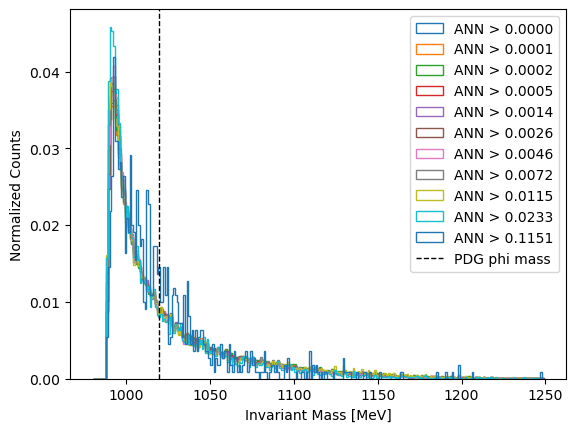

In [25]:
plt.figure()

for sel in np.percentile(test_df_bkg['ANN'],[0,10,20,30,40,50,60,70,80,90,99]):

    df_tritrig_cut = test_df_bkg[test_df_bkg['ANN']>sel].reset_index(drop=True)

    x_vals = 1000*df_tritrig_cut.InvM

    plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label=f'ANN > {sel:.4f}', density=True)

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

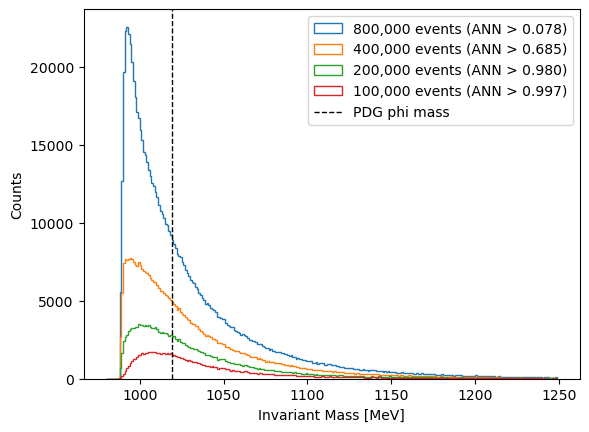

In [39]:
plt.figure()
for n_events in [800000, 400000, 200000, 100000]:
    ANN_selection = np.quantile(df_data['ANN'], 1 - n_events / len(df_data))
    df_data_cut = df_data[df_data['ANN'] > ANN_selection].reset_index(drop=True)
    x_vals = 1000 * df_data_cut.InvM
    plt.hist(x_vals, bins=np.arange(980, 1250, 1), histtype='step', label=f'{n_events:,} events (ANN > {ANN_selection:.3f})')

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()


In [43]:
QualCuts = {
    'pos_E_Ecal_low': 0.6,
    'pos_Px_low': -0.06,
    'ele_Ecal_z_low': 1448.6,
    'ele_Ecal_y_low': -85.0,
    'ele_Ecal_y_high': 85.0,
}

df_data_Qual = df_data[
    (df_data.pos_E_Ecal > QualCuts['pos_E_Ecal_low']) &
    (df_data.pos_Px > QualCuts['pos_Px_low']) &
    ( (df_data.ele_Ecal_z > QualCuts['ele_Ecal_z_low']) | (df_data['ele_Ecal_z'] < 0)) &
    (df_data.ele_Ecal_y > QualCuts['ele_Ecal_y_low']) &
    (df_data.ele_Ecal_y < QualCuts['ele_Ecal_y_high'])
]



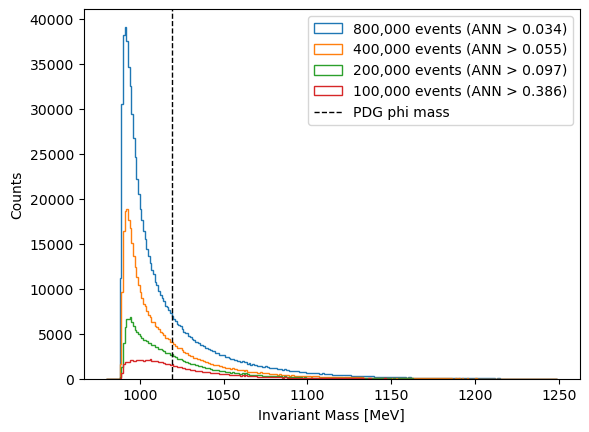

In [45]:


plt.figure()
for n_events in [800000, 400000, 200000, 100000]:
    ANN_selection = np.quantile(df_data_Qual['ANN'], 1 - n_events / len(df_data_Qual))
    df_data_cut = df_data_Qual[df_data_Qual['ANN'] > ANN_selection].reset_index(drop=True)
    x_vals = 1000 * df_data_cut.InvM
    plt.hist(x_vals, bins=np.arange(980, 1250, 1), histtype='step', label=f'{n_events:,} events (ANN > {ANN_selection:.3f})')

plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()


